# Laboratorio 10 - Visión Por Computadora

Autores:

- Nelson García
- Joaquín Puente
- Diego Linares

Link al repositorio: https://github.com/Its-Japo/VisionXComputadora/tree/main/Lab_10

# Task 1

En clase explicamos que la Difusión "esculpe" la imagen restando ruido de un tensor dentro del Espacio
Latente, paso a paso, antes de que el Decoder la convierta en píxeles. Usted deberá demostrar este
comportamiento interrumpiendo el proceso para observar la evolución temporal.

Instalar librerías necesarias:

In [1]:
!pip -q install -U diffusers transformers accelerate safetensors huggingface_hub matplotlib "pillow<12"

In [2]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    raise RuntimeError("Activa GPU en Colab: Entorno de ejecución > Cambiar tipo de entorno > GPU")

PyTorch: 2.12.0+cu130
CUDA disponible: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [3]:
#   Cargar Stable Diffusion 1.5 en GPU

from diffusers import StableDiffusionPipeline
from pathlib import Path
import matplotlib.pyplot as plt

device = "cuda"
model_id = "stable-diffusion-v1-5/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    use_safetensors=True
)

pipe = pipe.to(device)

# Ayuda a reducir memoria en Colab.
pipe.enable_attention_slicing()

print("Modelo cargado en:", pipe.device)
print("VAE scaling factor:", pipe.vae.config.scaling_factor)

/usr/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] `CLIPImageProcessor` requires torchvision (not installed); falling back to `CLIPImageProcessorPil` for backward compatibility. Install torchvision to use the default backend, or import `CLIPImageProcessorPil` directly to silence this warning.
[transformers] `SiglipImageProcessor` requires torchvision (not installed); falling back to `SiglipImageProcessorPil` for backward compatibility. Install torchvision to use the default backend, or import `SiglipImageProcessorPil` directly to silence this warning.
Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00, 10.42it/s]


Modelo cargado en: cuda:0
VAE scaling factor: 0.18215


In [4]:
#Interceptar los latentes en los pasos 4, 10, 16 y 20

prompt = "A highly detailed cinematic and futuristic fruit glowing in a cyberpunk laboratory, neon lights, 4k resolution"

num_inference_steps = 20
seed = 2026

# Se fija la semilla global y también el generador CUDA.
torch.manual_seed(seed)
generator = torch.Generator(device=device).manual_seed(seed)

capture_steps = {4, 10, 16, 20}
latents_by_step = {}

def capture_latents_callback(pipe, step_index, timestep, callback_kwargs):
    """
    step_index viene indexado desde 0.
    Por eso step_number = step_index + 1.
    """
    step_number = step_index + 1

    if step_number in capture_steps:
        latents = callback_kwargs["latents"]

        # Guardamos copia exacta en CPU para no modificar el proceso.
        latents_by_step[step_number] = latents.detach().clone().cpu()

        print(
            f"Latente guardado en paso {step_number:02d} | "
            f"shape={tuple(latents.shape)} | dtype={latents.dtype}"
        )

    return callback_kwargs

In [5]:
#Ejecutar el pipeline sin decodificar automáticamente la imagen final

with torch.inference_mode():
    _ = pipe(
        prompt=prompt,
        num_inference_steps=num_inference_steps,
        guidance_scale=7.5,
        generator=generator,
        callback_on_step_end=capture_latents_callback,
        callback_on_step_end_tensor_inputs=["latents"],
        output_type="latent"
    )

print("Pasos capturados:", sorted(latents_by_step.keys()))

 20%|██        | 4/20 [00:00<00:03,  4.75it/s]

Latente guardado en paso 04 | shape=(1, 4, 64, 64) | dtype=torch.float16


 50%|█████     | 10/20 [00:02<00:01,  5.70it/s]

Latente guardado en paso 10 | shape=(1, 4, 64, 64) | dtype=torch.float16


 80%|████████  | 16/20 [00:03<00:00,  5.78it/s]

Latente guardado en paso 16 | shape=(1, 4, 64, 64) | dtype=torch.float16


100%|██████████| 20/20 [00:03<00:00,  5.34it/s]

Latente guardado en paso 20 | shape=(1, 4, 64, 64) | dtype=torch.float16
Pasos capturados: [4, 10, 16, 20]


In [6]:
#Decodificar manualmente cada latente

def decode_latent_to_pil(latent_cpu, pipe):
    """
    Recibe un tensor latente guardado en CPU.
    Lo mueve a GPU, aplica el scaling_factor correcto,
    lo decodifica con el VAE y lo convierte a PIL.
    """
    latent = latent_cpu.to(device=pipe.device, dtype=pipe.vae.dtype)

    # Desescalado requerido antes del VAE.
    latent = latent / pipe.vae.config.scaling_factor

    with torch.inference_mode():
        image_tensor = pipe.vae.decode(latent, return_dict=False)[0]

    # Convierte tensor [-1, 1] a imagen PIL.
    image_pil = pipe.image_processor.postprocess(
        image_tensor,
        output_type="pil"
    )[0]

    return image_pil

In [7]:
out_dir = Path("resultados_task_1")
out_dir.mkdir(exist_ok=True)

decoded_images = {}

for step in [4, 10, 16, 20]:
    img = decode_latent_to_pil(latents_by_step[step], pipe)
    decoded_images[step] = img

    save_path = out_dir / f"latente_decodificado_paso_{step:02d}.png"
    img.save(save_path)

    print("Guardada:", save_path)

Guardada: resultados_task_1/latente_decodificado_paso_04.png
Guardada: resultados_task_1/latente_decodificado_paso_10.png
Guardada: resultados_task_1/latente_decodificado_paso_16.png
Guardada: resultados_task_1/latente_decodificado_paso_20.png


Mostrar resultados:

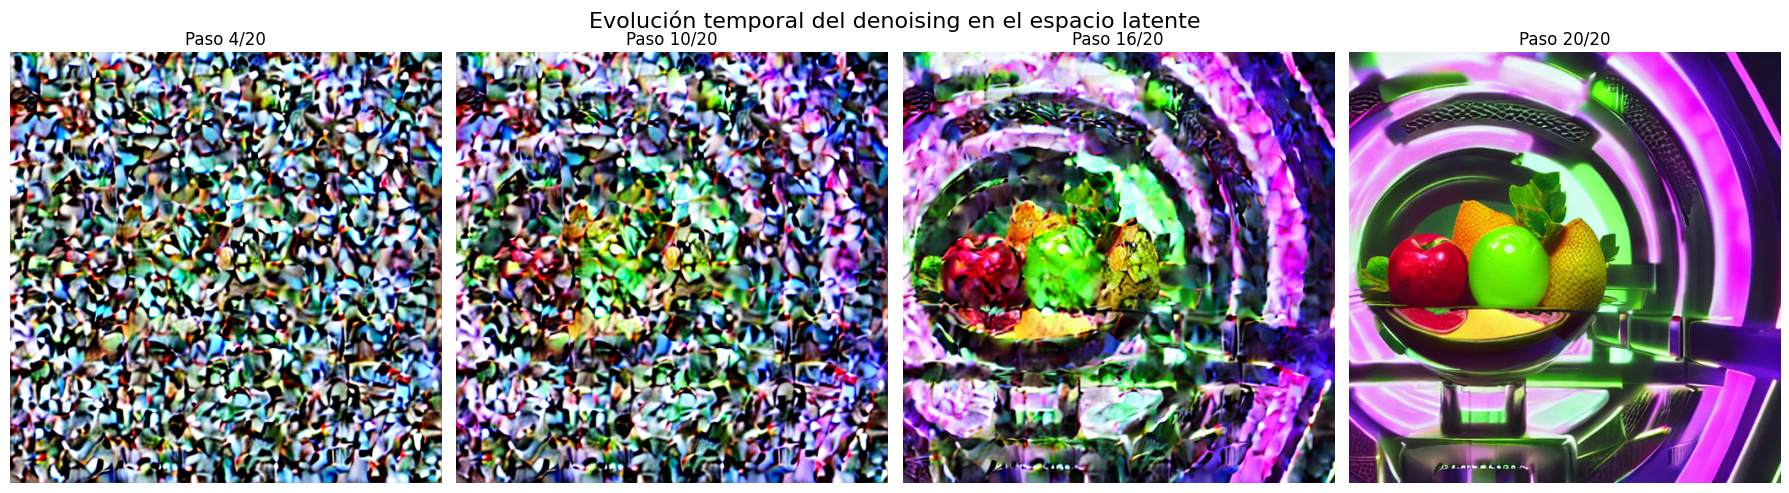

Cuadrícula guardada en: resultados_task_1/grid_evolucion_latentes.png


In [8]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, step in zip(axes, [4, 10, 16, 20]):
    ax.imshow(decoded_images[step])
    ax.set_title(f"Paso {step}/20")
    ax.axis("off")

plt.suptitle("Evolución temporal del denoising en el espacio latente", fontsize=16)
plt.tight_layout()

grid_path = out_dir / "grid_evolucion_latentes.png"
plt.savefig(grid_path, dpi=150, bbox_inches="tight")
plt.show()

print("Cuadrícula guardada en:", grid_path)

Observe la diferencia entre la imagen del paso 4 y la del paso 16. Explicado con base en la teoría de
frecuencias espaciales y Cross-Attention: ¿Qué características de la imagen (forma global, colores
bases, silueta vs. brillos, texturas finas, detalles del neón) resuelve la U-Net en las etapas iniciales
de ruido alto, y qué resuelve en las etapas finales de ruido bajo? Justifique técnicamente su
respuesta.

R//

En la comparación entre el paso 4 y el paso 16 se observa que la U-Net no resuelve todos los elementos visuales al mismo tiempo. En las etapas iniciales, cuando el nivel de ruido es alto, el modelo trabaja principalmente sobre componentes de baja frecuencia espacial: distribución general de masas, colores base, iluminación dominante y una posible silueta global. En cambio, en etapas posteriores, cuando el ruido ya es menor, la U-Net refina componentes de alta frecuencia espacial: bordes más definidos, brillos puntuales, texturas finas, detalles del neón y pequeñas variaciones locales.

En el paso 4, la imagen todavía parece una mezcla caótica de patrones, sin una forma semántica clara. Técnicamente, esto ocurre porque el tensor latente conserva mucho ruido y las altas frecuencias están dominadas por variaciones aleatorias. Por eso, la U-Net solo puede empezar a establecer una estructura global: zonas generales de color, contrastes amplios y una distribución aproximada de la composición. En esta etapa se empiezan a sugerir colores compatibles con el prompt, como verdes, magentas, cianes y tonos brillantes asociados al estilo cyberpunk, pero aún no aparecen detalles confiables de la fruta ni del laboratorio.

Desde la teoría de frecuencias espaciales, las bajas frecuencias representan cambios suaves y estructuras grandes: fondo, silueta, posición del objeto principal y paleta cromática general. Estas son más fáciles de estabilizar al inicio porque no requieren precisión píxel a píxel. Por eso, en ruido alto, el modelo prioriza la composición global antes que los detalles. La imagen del paso 4 contiene indicios de textura, pero esos patrones no son todavía detalles reales; son principalmente ruido organizado parcialmente.

En el paso 16, la imagen ya muestra una estructura mucho más reconocible. Se percibe una composición central, formas circulares o envolventes, mayor separación entre objeto y fondo, y colores neón más coherentes. Aquí la U-Net ya trabaja con un latente menos ruidoso, por lo que puede resolver frecuencias espaciales más altas: contornos, brillos, reflejos, pequeñas texturas y detalles visuales asociados al laboratorio futurista. Los patrones dejan de ser ruido puro y empiezan a convertirse en detalles semánticamente útiles.

La Cross-Attention guía este proceso porque conecta las palabras del prompt con regiones del latente. En las primeras etapas, términos como fruit, cyberpunk laboratory y neon lights influyen de forma global: ayudan a decidir qué tipo de escena se está formando, qué colores dominarán y dónde podría ubicarse el objeto principal. En las etapas finales, esa atención se vuelve más específica: refuerza detalles locales relacionados con “glowing”, “neon lights”, “highly detailed” y “futuristic”, haciendo que aparezcan brillos, texturas complejas y efectos visuales más finos.

Por lo tanto, la U-Net primero resuelve la estructura de baja frecuencia: forma global, composición, colores base y silueta aproximada. Después, en etapas de menor ruido, resuelve la estructura de alta frecuencia: bordes definidos, texturas finas, reflejos, detalles luminosos y elementos de neón. Esto justifica que el paso 4 se vea más abstracto y ruidoso, mientras que el paso 16 ya presenta una imagen visualmente más organizada y alineada con el prompt.

# Task 2
Como vimos al final de la sesión, el modelo Nano Banana de Google representa la vanguardia en
eficiencia: usar técnicas de destilación para saltarse pasos matemáticos de la Cadena de Markov y correr
modelos generativos en milisegundos. Usted simulará este escenario midiendo empíricamente el trade-off
(costo-beneficio) en producción.

## Escenario A — Modelo Estándar (SD 1.5, 50 pasos)

In [9]:
import time
import gc

prompt = "A highly detailed cinematic and futuristic fruit glowing in a cyberpunk laboratory, neon lights, 4k resolution"
seed = 2026

# Limpiar estadísticas de VRAM antes de medir
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

generator_a = torch.Generator(device=device).manual_seed(seed)

t0_a = time.time()

with torch.inference_mode():
    result_a = pipe(
        prompt=prompt,
        num_inference_steps=50,
        guidance_scale=7.5,
        generator=generator_a,
    )

t1_a = time.time()

image_a = result_a.images[0]
time_a = t1_a - t0_a
vram_a = torch.cuda.max_memory_allocated() / (1024 ** 2)  # MB

image_a.save("escenario_A_sd15_50pasos.png")
print(f"Escenario A  |  Tiempo: {time_a:.2f} s  |  VRAM pico: {vram_a:.0f} MB")

100%|██████████| 50/50 [00:08<00:00,  5.67it/s]


Escenario A  |  Tiempo: 9.05 s  |  VRAM pico: 3257 MB


## Escenario B — Modelo Destilado (SD-Turbo, 4 pasos)

In [10]:
from diffusers import AutoPipelineForText2Image

# Liberar memoria del pipeline anterior para maximizar VRAM disponible
del pipe
gc.collect()
torch.cuda.empty_cache()

model_id_turbo = "stabilityai/sd-turbo"

pipe_turbo = AutoPipelineForText2Image.from_pretrained(
    model_id_turbo,
    torch_dtype=torch.float16,
    variant="fp16",
)
pipe_turbo = pipe_turbo.to(device)
pipe_turbo.enable_attention_slicing()

print("Modelo SD-Turbo cargado en:", pipe_turbo.device)

[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.
/home/Japo/Workspaces/uvg/VisionXCompotadora/Lab_10/.venv/lib/python3.14/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Loading pipeline components...: 100%|██████████| 5/5 [00:00<00:00, 30.44it/s]
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, di

Modelo SD-Turbo cargado en: cuda:0


In [11]:
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

generator_b = torch.Generator(device=device).manual_seed(seed)

t0_b = time.time()

with torch.inference_mode():
    result_b = pipe_turbo(
        prompt=prompt,
        num_inference_steps=4,
        guidance_scale=0.0,   # SD-Turbo es un modelo sin CFG (guidance_scale=0)
        generator=generator_b,
    )

t1_b = time.time()

image_b = result_b.images[0]
time_b = t1_b - t0_b
vram_b = torch.cuda.max_memory_allocated() / (1024 ** 2)  # MB

image_b.save("escenario_B_sdturbo_4pasos.png")
print(f"Escenario B  |  Tiempo: {time_b:.2f} s  |  VRAM pico: {vram_b:.0f} MB")

100%|██████████| 4/4 [00:00<00:00, 13.00it/s]


Escenario B  |  Tiempo: 0.56 s  |  VRAM pico: 3099 MB


## Resultados comparativos

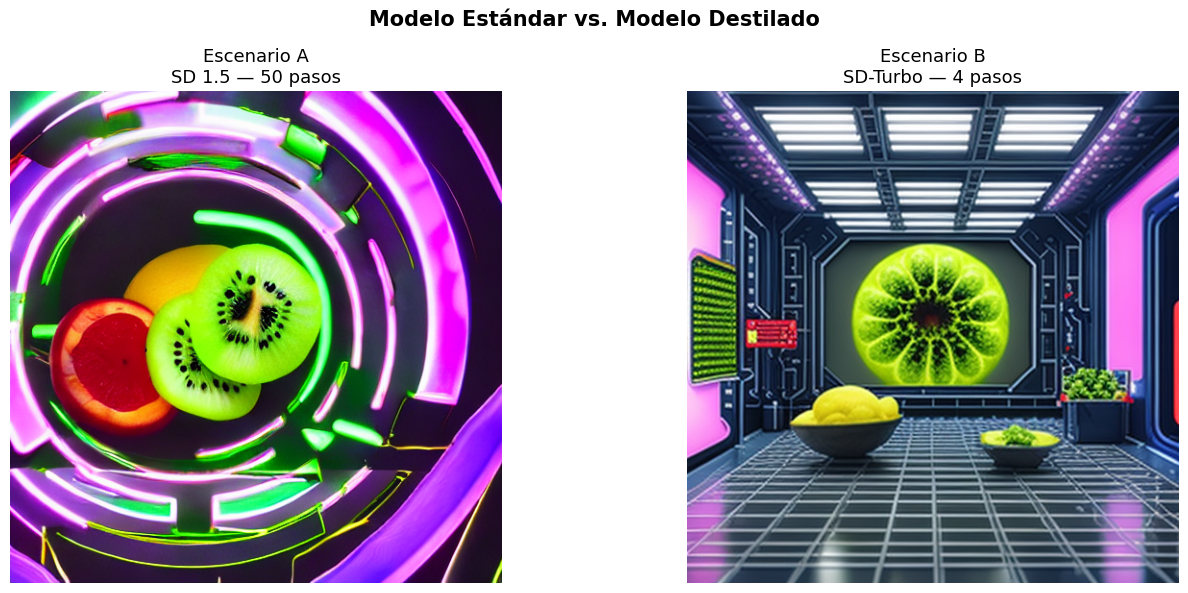


Métrica                           Escenario A        Escenario B
------------------------------------------------------------------
Modelo                                 SD 1.5           SD-Turbo
Pasos de inferencia                        50                  4
Tiempo de ejecución                    9.05 s             0.56 s
VRAM pico                             3257 MB            3099 MB

Aceleración: 16.3x más rápido en Escenario B
Ahorro de VRAM: 4.9% menos en Escenario B


In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(image_a)
axes[0].set_title("Escenario A\nSD 1.5 — 50 pasos", fontsize=13)
axes[0].axis("off")

axes[1].imshow(image_b)
axes[1].set_title("Escenario B\nSD-Turbo — 4 pasos", fontsize=13)
axes[1].axis("off")

plt.suptitle("Modelo Estándar vs. Modelo Destilado", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("comparacion_task2.png", dpi=150, bbox_inches="tight")
plt.show()

# Tabla comparativa
sep = "=" * 66
row = "-" * 66
print(f"\n{sep}")
print(f"{'Métrica':<26} {'Escenario A':>18} {'Escenario B':>18}")
print(row)
print(f"{'Modelo':<26} {'SD 1.5':>18} {'SD-Turbo':>18}")
print(f"{'Pasos de inferencia':<26} {50:>18} {4:>18}")
print(f"{'Tiempo de ejecución':<26} {f'{time_a:.2f} s':>18} {f'{time_b:.2f} s':>18}")
print(f"{'VRAM pico':<26} {f'{vram_a:.0f} MB':>18} {f'{vram_b:.0f} MB':>18}")
print(sep)
print(f"\nAceleración: {time_a / time_b:.1f}x más rápido en Escenario B")
if vram_a > vram_b:
    print(f"Ahorro de VRAM: {(vram_a - vram_b) / vram_a * 100:.1f}% menos en Escenario B")
else:
    print(f"VRAM Escenario B: {vram_b:.0f} MB  (modelos similares en tamaño, la diferencia está en los pasos)")

### Analisis tecnico y dictamen de produccion

**Respuesta sobre destilacion**

La diferencia principal entre el Escenario A y el Escenario B no es solo la cantidad de pasos, sino como fue entrenado cada modelo para recorrer el proceso de denoising. El modelo estandar SD 1.5 aprende a transformar ruido latente en imagen siguiendo una trayectoria relativamente larga del scheduler. Cada paso corrige una parte pequena del tensor: reduce ruido residual, ajusta la composicion, refuerza lo que la Cross-Attention esta asociando con el prompt y deja listo el latente para el siguiente paso. Por eso, si se obliga al modelo estandar a trabajar con solo 4 pasos, cada actualizacion queda demasiado grande y el modelo no alcanza a limpiar ni organizar bien el latente; el resultado tiende a ser ruido, formas incompletas o una imagen poco usable.

El modelo destilado SD-Turbo, en cambio, fue entrenado para imitar el comportamiento de un modelo mas costoso en muchos menos pasos. La destilacion comprime la trayectoria del modelo profesor: en lugar de necesitar decenas de pequenas correcciones, el modelo aprende saltos mas grandes y mas directos desde un latente ruidoso hacia una imagen coherente. Por eso puede producir una escena reconocible en 4 pasos: no esta usando el mismo regimen de inferencia que SD 1.5 reducido artificialmente, sino una arquitectura/pesos calibrados para pocos pasos, con guidance_scale=0.0 y un scheduler compatible con ese uso.

**Analisis de metricas y calidad visual**

En las metricas obtenidas, el Escenario A tardo 9.05 segundos con 3257 MB de VRAM pico, mientras que el Escenario B tardo 0.56 segundos con 3099 MB de VRAM pico. Esto significa que SD-Turbo fue aproximadamente 16.3 veces mas rapido, aunque el ahorro de memoria fue bajo, alrededor de 4.9%. La mejora fuerte, entonces, no esta tanto en cargar un modelo mucho mas liviano, sino en ejecutar muchos menos pasos de denoising. Para una API con millones de usuarios, esa reduccion de tiempo impacta directamente en latencia, costo por solicitud, cantidad de GPUs necesarias y capacidad de atender mas trafico con el mismo hardware.

Visualmente, el Escenario A produce una imagen con mas detalle fino en las frutas, brillos de neon mas intensos y una composicion mas cercana al estilo cinematografico del prompt. El Escenario B tambien genera una imagen coherente y alineada con la idea de laboratorio futurista, pero se ve mas simple: las texturas son menos ricas, el objeto principal es menos complejo y algunos detalles se sienten mas suaves o menos refinados. Esto muestra el trade-off esperado: el modelo estandar gana en calidad y detalle cuando hay tiempo para 50 pasos, mientras que el modelo destilado sacrifica parte de esa riqueza visual para responder mucho mas rapido.

Como arquitecto de IA, para una aplicacion con millones de usuarios elegiria el **Escenario B como opcion principal de produccion**. La razon es que la aceleracion de 16.3x reduce mucho el costo operativo y permite una experiencia interactiva con menor latencia. La calidad visual del modelo destilado no es perfecta, pero si es suficientemente coherente para un flujo masivo donde importan velocidad, escalabilidad y costo por imagen. Dejaria el Escenario A para casos premium, generacion final de alta calidad o procesos offline donde el usuario pueda esperar mas tiempo y el costo adicional este justificado.
